<a href="https://colab.research.google.com/github/AkshataJv/InsightCart/blob/main/InsightCart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")

In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


# Data Preprocessing

1. Handle Missing Values

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# Feature Engineering

In [8]:
# Age
df["Age"] = 2026-df["Year_Birth"]

In [9]:
# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [10]:
# Spending
df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"]  + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

In [11]:
# Children
df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [12]:
# Education
df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate",
    "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

In [13]:
df["Education"].value_counts()

,count
Education,
Graduate,1127
Postgraduate,856
Undergraduate,257


In [14]:
# Marital Status
df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner",
    "Together": "Partner",
    "Single": "Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Absurd": "Alone",
    "YOLO": "Alone"
})

In [15]:
df["Living_With"].value_counts()

,count
Living_With,
Partner,1444
Alone,796


# Drop Columns

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


In [17]:
cols = ["ID","Year_Birth", "Marital_Status","Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [18]:
df_cleaned.shape

(2240, 15)

In [19]:
df.shape

(2240, 27)

In [20]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Outliers

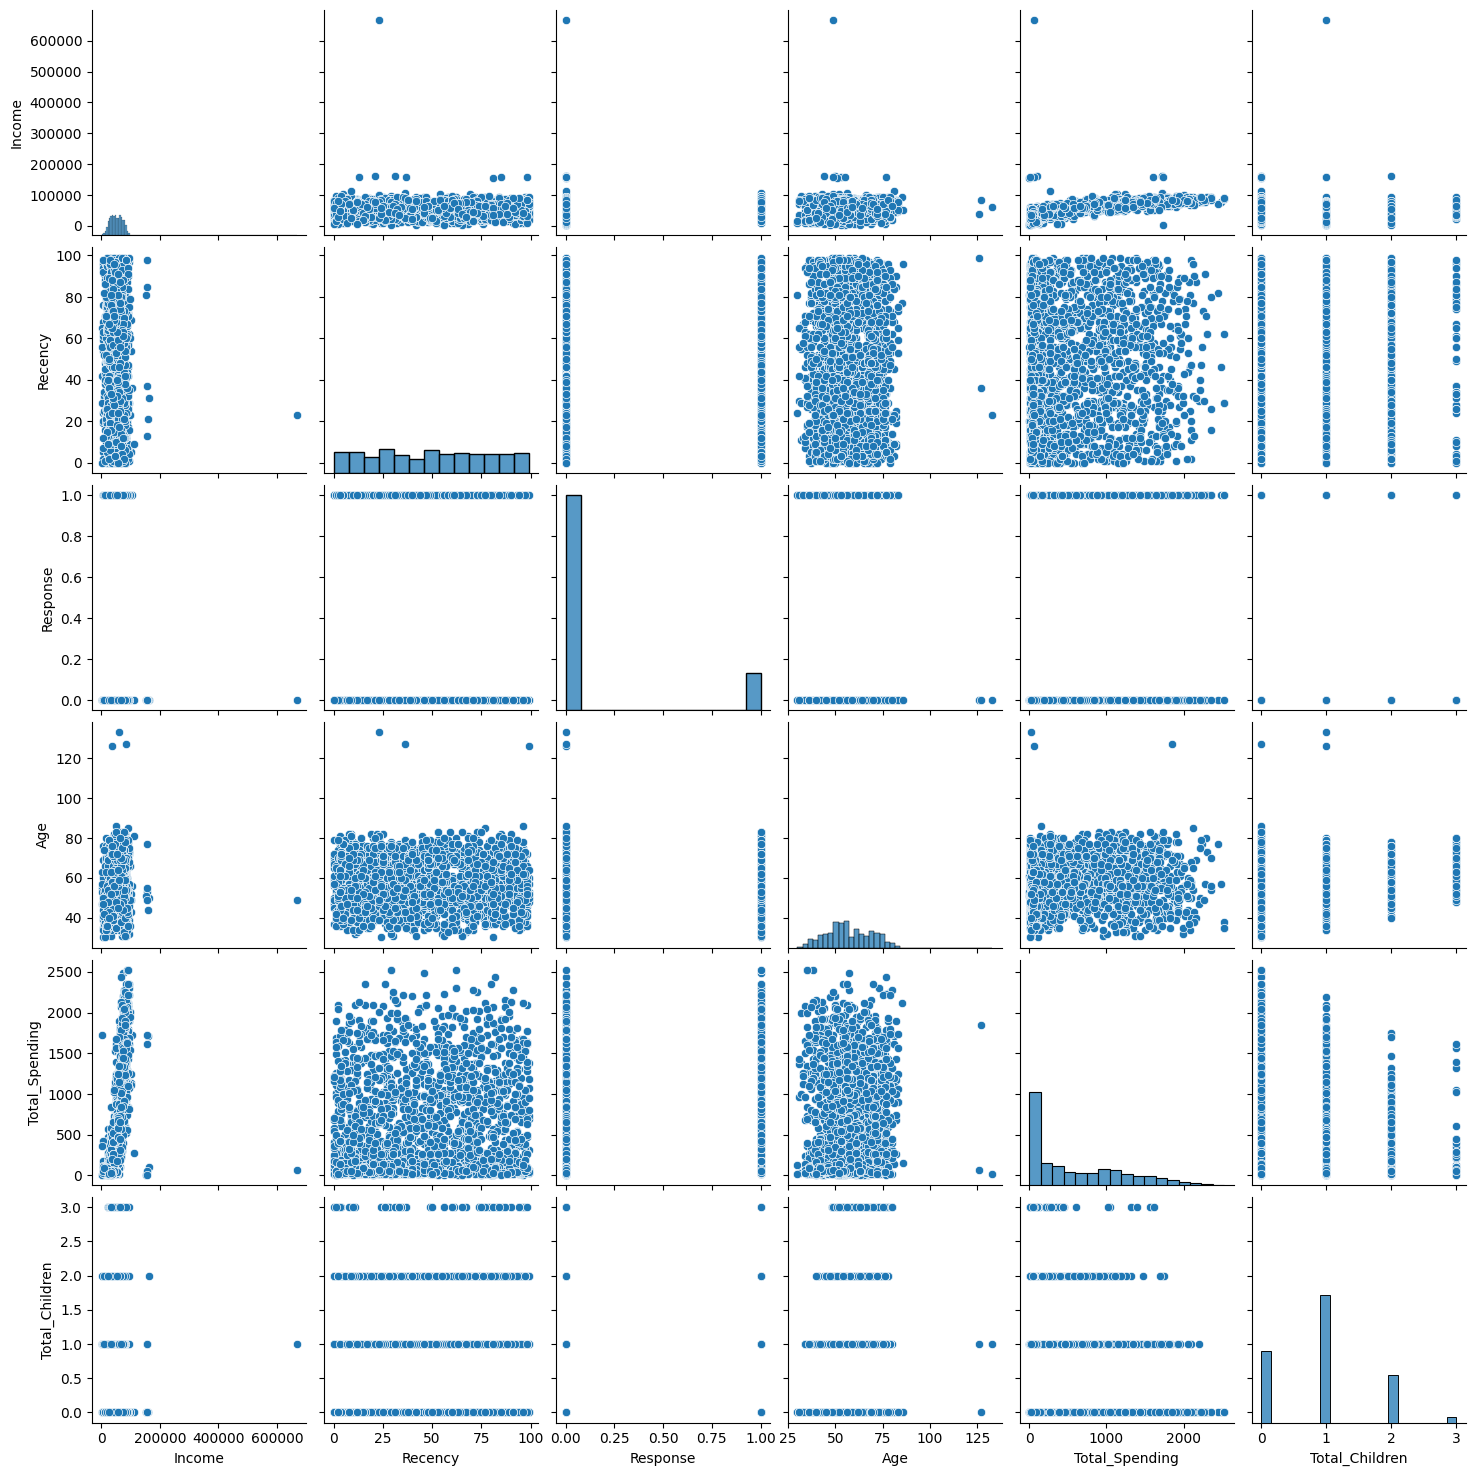

In [21]:
cols = ["Income","Recency", "Response",	"Age", "Total_Spending", "Total_Children" ]

# Relative plots of some features- pair plots
sns.pairplot(df_cleaned[cols])


In [22]:
# Remove Outliers

print("data size with outliers: ", len(df_cleaned))

df_cleaned = df_cleaned[df_cleaned["Age"] < 90]
df_cleaned = df_cleaned[df_cleaned["Income"] < 600000]

print("data size with outliers: ", len(df_cleaned))

data size with outliers:  2240
data size with outliers:  2236


# HeatMap

<Axes: >

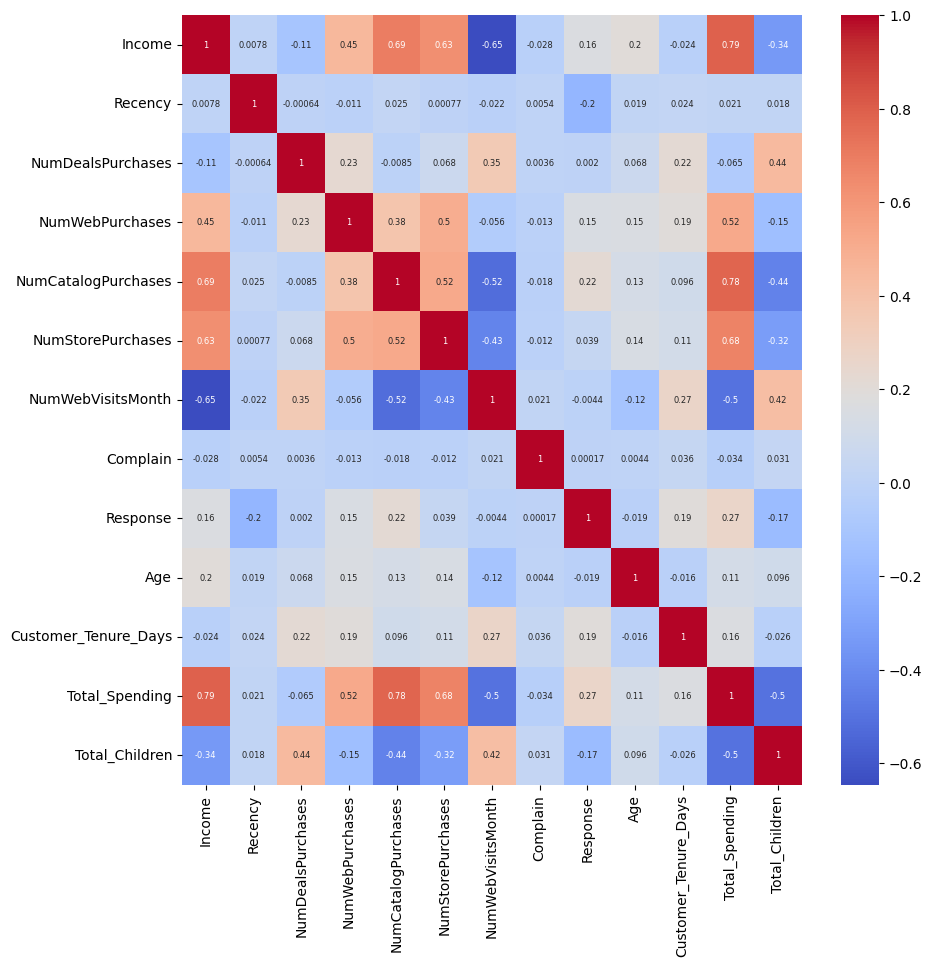

In [23]:
# Corelation matrix
plt.figure(figsize=(10, 10))

corr = df_cleaned.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size": 6},
    cmap="coolwarm"
)

In [24]:
df_cleaned.shape

(2236, 15)

In [25]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner


# Encoding

In [26]:
from sklearn.preprocessing import OneHotEncoder

In [27]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]
enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [28]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out())

In [29]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis=1)

In [30]:
df_encoded.shape

(2240, 18)

In [31]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58.0,3.0,8.0,10.0,4.0,7.0,0.0,1.0,69.0,663.0,1617.0,0.0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38.0,2.0,1.0,1.0,2.0,5.0,0.0,0.0,72.0,113.0,27.0,2.0,1.0,0.0,0.0,1.0,0.0
2,71613.0,26.0,1.0,8.0,2.0,10.0,4.0,0.0,0.0,61.0,312.0,776.0,0.0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26.0,2.0,2.0,0.0,4.0,6.0,0.0,0.0,42.0,139.0,53.0,1.0,1.0,0.0,0.0,0.0,1.0
4,58293.0,94.0,5.0,5.0,3.0,6.0,5.0,0.0,0.0,45.0,161.0,422.0,1.0,0.0,1.0,0.0,0.0,1.0


# Scaling

In [32]:
from sklearn.preprocessing import StandardScaler

In [33]:
X = df_encoded

In [34]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualization

In [35]:
X_scaled.shape

(2240, 18)

In [36]:
#2D
from sklearn.decomposition import PCA

In [37]:
import numpy as np
from sklearn.decomposition import PCA

pca = PCA(n_components=3)

X_scaled = X_scaled[~np.isnan(X_scaled).any(axis=1)]

X_pca = pca.fit_transform(X_scaled)

In [38]:
pca.explained_variance_ratio_

array([0.23037727, 0.11213209, 0.10138009])

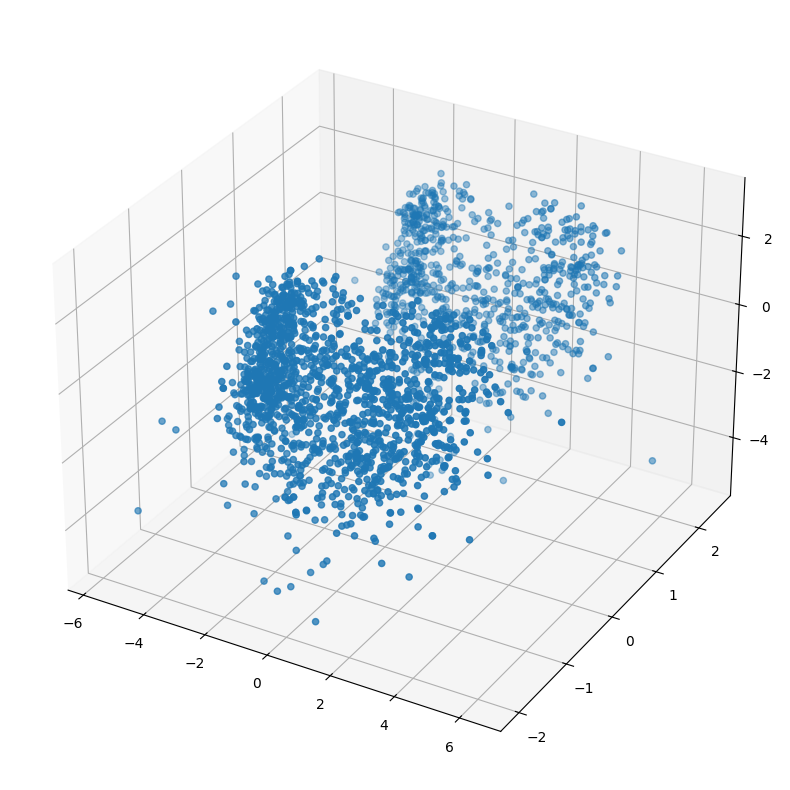

In [39]:
# plot
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

In [40]:
pca.explained_variance_ratio_

array([0.23037727, 0.11213209, 0.10138009])

# Analyze K Value

In [41]:
!pip install kneed
from sklearn.cluster import KMeans
from kneed import KneeLocator

WCSS = []
for k in range(1, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  kmeans.fit_predict(X_pca)
  WCSS.append(kmeans.inertia_)

In [42]:
knee = KneeLocator(range(1, 11), WCSS, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [43]:
print("best k =", optimal_k)

best k = 4


Text(0, 0.5, 'WCSS')

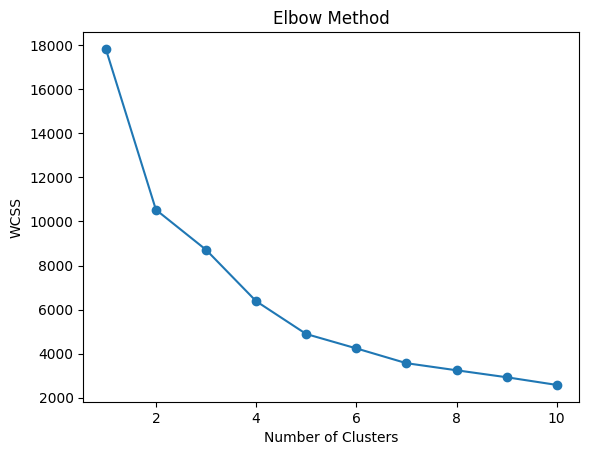

In [44]:
# Plot

plt.plot(range(1, 11), WCSS, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

## 2. Silhouette Score

Text(0, 0.5, 'Silhouette Score')

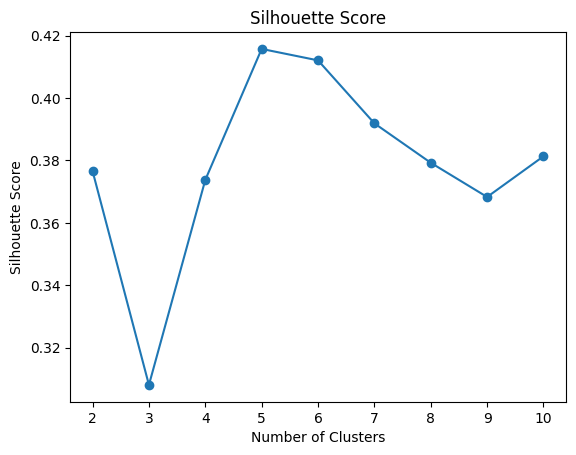

In [45]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2, 11):
  kmeans = KMeans(n_clusters=k, random_state=42)
  labels = kmeans.fit_predict(X_pca)
  score = silhouette_score(X_pca, kmeans.labels_)
  scores.append(score)

# Plot
plt.plot(range(2, 11), scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

Text(0, 0.5, 'SS')

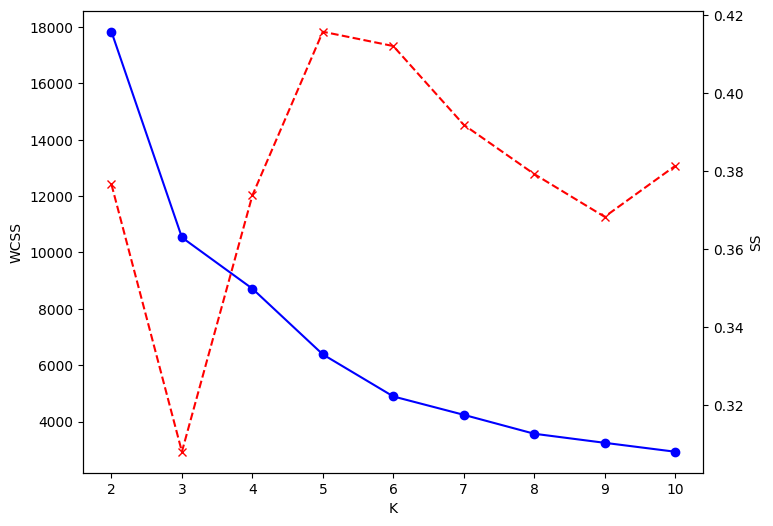

In [46]:
# combined plot

k_range = range(2, 11)

fig, ax1 = plt.subplots(figsize=(8, 6))

ax1.plot(k_range, WCSS[:len(k_range)], marker="o", color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker="x", color="red", linestyle="--")
ax2.set_ylabel("SS")

# Clustering

In [47]:
# k_means

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X_pca)

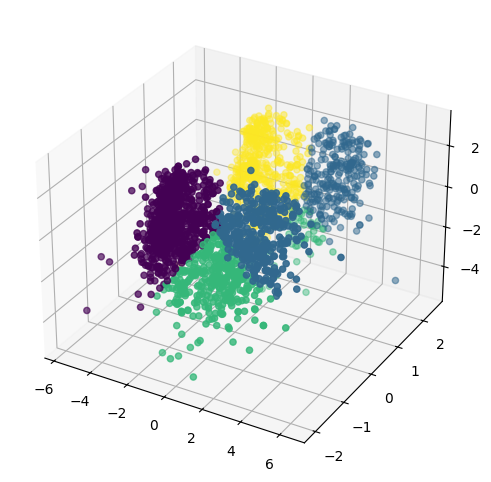

In [48]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels)

In [49]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [50]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

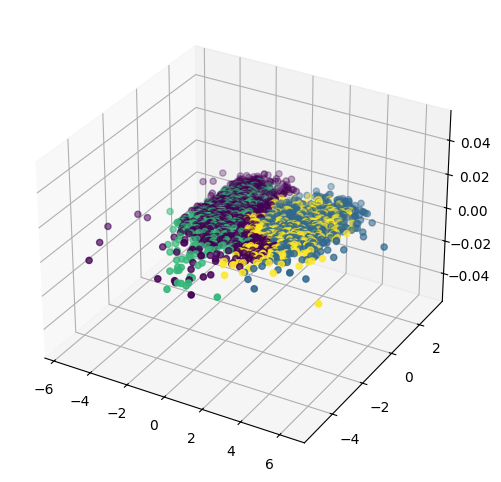

In [51]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 2], c=labels_agg)

# Characterization of Clusters

In [52]:
df_cleaned = df_cleaned.reset_index(drop=True)
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols), enc_df], axis=1)

X = df_encoded
X_scaled = scaler.fit_transform(X)

mask_non_nan = ~np.isnan(X_scaled).any(axis=1)
X_scaled_filtered = X_scaled[mask_non_nan]

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled_filtered)

df_cleaned = df_cleaned[mask_non_nan].reset_index(drop=True)
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X_pca)

df_cleaned["Cluster"] = labels

print(f"Shape of df_cleaned after alignment: {df_cleaned.shape}")
print(f"Length of labels after re-clustering: {len(labels)}")

Shape of df_cleaned after alignment: (2236, 16)
Length of labels after re-clustering: 2236


In [53]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With,Cluster
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,2
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,3
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,2
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,1


<Axes: xlabel='Cluster', ylabel='count'>

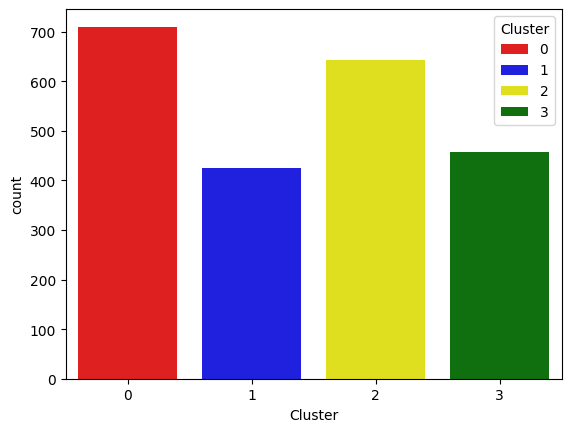

In [58]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(data=df_cleaned, x = df_cleaned["Cluster"], palette=pal, hue=df_cleaned["Cluster"])

<Axes: xlabel='Income', ylabel='Total_Spending'>

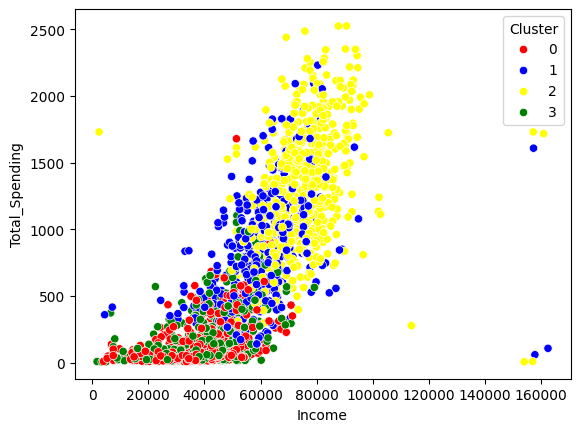

In [56]:
# Income & Spending Patterns

sns.scatterplot(x=df_cleaned["Income"], y=df_cleaned["Total_Spending"], hue=df_cleaned["Cluster"], palette=pal)

In [60]:
# Cluster Summery

cluster_summer = df_cleaned.groupby("Cluster").mean(numeric_only=True)
print(cluster_summer)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
Cluster                                                                
0        35604.642254  49.688732           2.176056         2.411268   
1        59857.395540  48.335681           3.645540         6.323944   
2        74671.218847  49.767913           1.510903         5.356698   
3        38097.327511  48.041485           2.473799         2.827511   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
Cluster                                                                        
0                   0.605634           3.494366           6.481690  0.011268   
1                   3.476526           7.600939           5.577465  0.004695   
2                   5.665109           8.559190           3.021807  0.007788   
3                   0.888646           3.810044           6.495633  0.010917   

         Response        Age  Customer_Tenure_Days  Total_Spending  \
Cluster         